# **`NAME : HIMANK DEO`**
# **`E-MAIL : deo.himank@gmail.com`**

# **Netflix Recommendation Engine**

**What are Recommender Systems?**

Recommender systems are algorithms designed to suggest relevant items to users. These systems are used in various domains such as e-commerce, streaming services, and social media. They enhance user experience by filtering vast amounts of information to deliver personalized content.

# SVD (Singular Value Decomposition) in a recommendation system works by finding patterns in user preferences and item similarities.

Here's a basic idea without going deep into the topic

**1) What the System Has: A big table (matrix) with users on one side and items (like movies) on the other. Users give ratings to items, but not everyone has rated everything**

**2) What SVD Does: SVD looks at the ratings that are available and tries to figure out the hidden connections between users and items. It learns what kind of movies users like based on their previous ratings**

**3) How It Helps: Once SVD understands these patterns, it can predict how a user might rate a movie they haven’t seen yet. Based on these predictions, the system recommends movies that the user is most likely to enjoy**

## Importing Libraries

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from statsmodels.tools.sm_exceptions import ConvergenceWarning
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore',ConvergenceWarning)
print("✅ Imported!")

✅ Imported!


## Data Inspection

In [4]:
df=pd.read_csv('combined_data_1.txt',header = None, names=['Cust_ID','Rating'],usecols=[0,1])

In [5]:
df

,Cust_ID,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0
...,...,...
24058258,2591364,2.0
24058259,1791000,2.0
24058260,512536,5.0
24058261,988963,3.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24058263 entries, 0 to 24058262
Data columns (total 2 columns):
 #   Column   Dtype  
---  ------   -----  
 0   Cust_ID  object 
 1   Rating   float64
dtypes: float64(1), object(1)
memory usage: 367.1+ MB


In [7]:
df.isna().sum()

Cust_ID       0
Rating     4499
dtype: int64

## EDA - Exploratory Data Analysis

In [8]:
movie_count=df.isna().sum()
movie_count=movie_count['Rating']
movie_count

4499

In [9]:
total=df['Cust_ID'].nunique()
customer_count=total - movie_count
customer_count

470758

In [10]:

rating_count=df['Cust_ID'].count()-movie_count  # In Customer id column we will remove movie id to get how many total rating are there
rating_count

24053764

In [11]:
rate = df.groupby('Rating')['Rating'].agg(['count'])
rate

,count
Rating,
1.0,1118186
2.0,2439073
3.0,6904181
4.0,8085741
5.0,5506583


Text(0.5, 1.0, 'Total pool: 4499, Movies 470758, Customers 470758, Rating given')

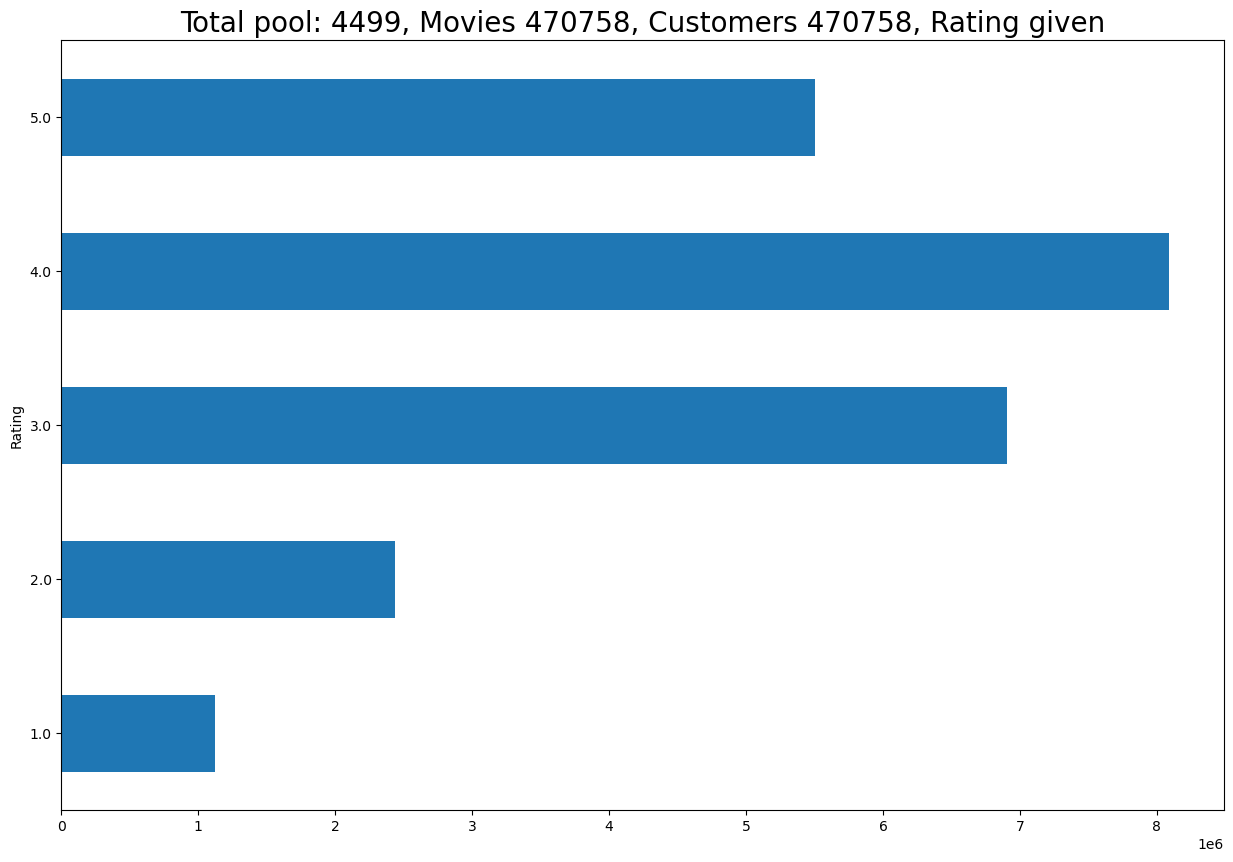

In [12]:
ax=rate.plot(kind='barh',legend=False,figsize=(15,10))
plt.title(f'Total pool: {movie_count}, Movies {customer_count}, Customers {customer_count}, Rating given', fontsize=20)

In [13]:
movie_id=None
movie_np =[]
for i in df['Cust_ID']:
    if':' in i :
        movie_id = int(i.replace(':',""))
    movie_np.append(movie_id)

In [14]:
movie_np

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,


In [15]:
df['Movie_ID']=movie_np

In [16]:
df

,Cust_ID,Rating,Movie_ID
0,1:,NaN,1
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
...,...,...,...
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499


In [17]:
df = df[df['Rating'].notna()]

In [18]:
df

,Cust_ID,Rating,Movie_ID
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
5,823519,3.0,1
...,...,...,...
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_ID   object 
 1   Rating    float64
 2   Movie_ID  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 734.1+ MB


In [20]:
df['Cust_ID']=pd.to_numeric(df['Cust_ID'])

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_ID   int64  
 1   Rating    float64
 2   Movie_ID  int64  
dtypes: float64(1), int64(2)
memory usage: 734.1 MB


In [22]:
dataset_movies_summary= df.groupby('Movie_ID')['Rating'].agg(["count"])

In [23]:
dataset_movies_summary

,count
Movie_ID,
1,547
2,145
3,2012
4,142
5,1140
...,...
4495,614
4496,9519
4497,714


In [24]:
movie_benchmark=round(dataset_movies_summary['count'].quantile(0.6),0)
movie_benchmark

908.0

In [25]:
drop_movies_list = dataset_movies_summary[dataset_movies_summary['count']<movie_benchmark].index
drop_movies_list

Index([   1,    2,    4,    7,    9,   10,   11,   12,   13,   14,
       ...
       4480, 4481, 4486, 4487, 4491, 4494, 4495, 4497, 4498, 4499],
      dtype='int64', name='Movie_ID', length=2699)

In [26]:
customer_summary= df.groupby('Cust_ID')['Rating'].agg(["count"])
customer_summary

,count
Cust_ID,
6,153
7,195
8,21
10,49
25,4
...,...
2649404,12
2649409,10
2649421,3


In [27]:
customer_benchmark = round(customer_summary['count'].quantile(0.6),0)
customer_benchmark

36.0

In [28]:
drop_customer_list= customer_summary[customer_summary['count']<customer_benchmark].index

## Removing all the movies that has been rated less by the customers and all customers that have rated less movies.

In [29]:
df = df[~df['Movie_ID'].isin(drop_movies_list)]
df = df[~df['Cust_ID'].isin(drop_customer_list)]

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19695836 entries, 696 to 24056846
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_ID   int64  
 1   Rating    float64
 2   Movie_ID  int64  
dtypes: float64(1), int64(2)
memory usage: 601.1 MB


# Model Building 

In [31]:
title = pd.read_csv('movie_titles _1_.csv',encoding='latin',header=None,usecols=[0,1,2],names=['Movie_ID','Year','Name'])
title

,Movie_ID,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [32]:
#!pip install surprise

In [33]:
from surprise import Reader, Dataset, SVD
from surprise.model_selection import cross_validate

In [34]:
reader = Reader()
data = Dataset.load_from_df(df[['Cust_ID','Movie_ID','Rating']],reader)

In [35]:
model = SVD()

In [36]:
cross_validate(model,data,measures=['RMSE'],cv=3)

{'test_rmse': array([0.86802585, 0.86804683, 0.86791948]),
 'fit_time': (291.95468306541443, 275.4468631744385, 279.19426465034485),
 'test_time': (120.84471249580383, 126.20991063117981, 113.99826407432556)}

## Use model for recomendation system for specific user

In [37]:
df

,Cust_ID,Rating,Movie_ID
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3
...,...,...,...
24056842,1055714,5.0,4496
24056843,2643029,4.0,4496
24056844,267802,4.0,4496
24056845,1559566,3.0,4496


In [38]:
title

,Movie_ID,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [39]:
# Fitering the data set for specific user you have selected to make recomendation to that user
user_ratings = df[df['Cust_ID']==2632461]
user_ratings

,Cust_ID,Rating,Movie_ID
698,2632461,3.0,3
93404,2632461,3.0,30
577895,2632461,4.0,175
1296724,2632461,4.0,290
1498351,2632461,2.0,312
1671074,2632461,3.0,329
2600549,2632461,3.0,482
3014577,2632461,4.0,571
3395020,2632461,4.0,645
3578127,2632461,2.0,692


In [40]:
movies_rated_by_user = user_ratings['Movie_ID'].nunique()
print(f"User 2632461 has rated {movies_rated_by_user} unique movies.")

User 2632461 has rated 53 unique movies.


In [41]:
# Making a copy for each individual customer for the recomendation 
data_for_user = title.copy() 
data_for_user

,Movie_ID,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [42]:
# Removing the movie less then benchmark for this user
copy_data_for_user = data_for_user[~data_for_user['Movie_ID'].isin(drop_movies_list)]
copy_data_for_user

,Movie_ID,Year,Name
2,3,1997.0,Character
4,5,2004.0,The Rise and Fall of ECW
5,6,1997.0,Sick
7,8,2004.0,What the #$*! Do We Know!?
15,16,1996.0,Screamers
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [43]:
copy_data_for_user['Estimate_Score']=copy_data_for_user['Movie_ID'].apply(lambda x: model.predict(2632461,x).est)

In [44]:
copy_data_for_user

,Movie_ID,Year,Name,Estimate_Score
2,3,1997.0,Character,3.371676
4,5,2004.0,The Rise and Fall of ECW,3.520653
5,6,1997.0,Sick,1.913913
7,8,2004.0,What the #$*! Do We Know!?,2.919219
15,16,1996.0,Screamers,2.998028
...,...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...,3.303126
17766,17767,2004.0,Fidel Castro: American Experience,3.303126
17767,17768,2000.0,Epoch,3.303126
17768,17769,2003.0,The Company,3.303126


In [45]:
copy_data_for_user.sort_values('Estimate_Score',ascending = False)

,Movie_ID,Year,Name,Estimate_Score
4426,4427,2001.0,The West Wing: Season 3,4.843983
2161,2162,2000.0,CSI: Season 1,4.603858
3455,3456,2004.0,Lost: Season 1,4.459785
4352,4353,2002.0,Curb Your Enthusiasm: Season 3,4.410940
2451,2452,2001.0,Lord of the Rings: The Fellowship of the Ring,4.339876
...,...,...,...,...
3566,3567,2004.0,Starship Troopers 2: Hero of the Federation,1.618758
2842,2843,2005.0,Last Days,1.583886
3219,3220,2001.0,Xena: Warrior Princess: Series Finale,1.557063
4393,4394,2001.0,Druids,1.544836


In [46]:
top5 = copy_data_for_user.sort_values('Estimate_Score',ascending = False).head(5)
top5

,Movie_ID,Year,Name,Estimate_Score
4426,4427,2001.0,The West Wing: Season 3,4.843983
2161,2162,2000.0,CSI: Season 1,4.603858
3455,3456,2004.0,Lost: Season 1,4.459785
4352,4353,2002.0,Curb Your Enthusiasm: Season 3,4.410940
2451,2452,2001.0,Lord of the Rings: The Fellowship of the Ring,4.339876


In [47]:
top5_list = top5[['Name', 'Year', 'Estimate_Score']].to_dict('records')
print(top5_list)

[{'Name': 'The West Wing: Season 3', 'Year': 2001.0, 'Estimate_Score': 4.843982512990955}, {'Name': 'CSI: Season 1', 'Year': 2000.0, 'Estimate_Score': 4.603857851839772}, {'Name': 'Lost: Season 1', 'Year': 2004.0, 'Estimate_Score': 4.4597850997856545}, {'Name': 'Curb Your Enthusiasm: Season 3', 'Year': 2002.0, 'Estimate_Score': 4.41094018431259}, {'Name': 'Lord of the Rings: The Fellowship of the Ring', 'Year': 2001.0, 'Estimate_Score': 4.339875945982608}]
